In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

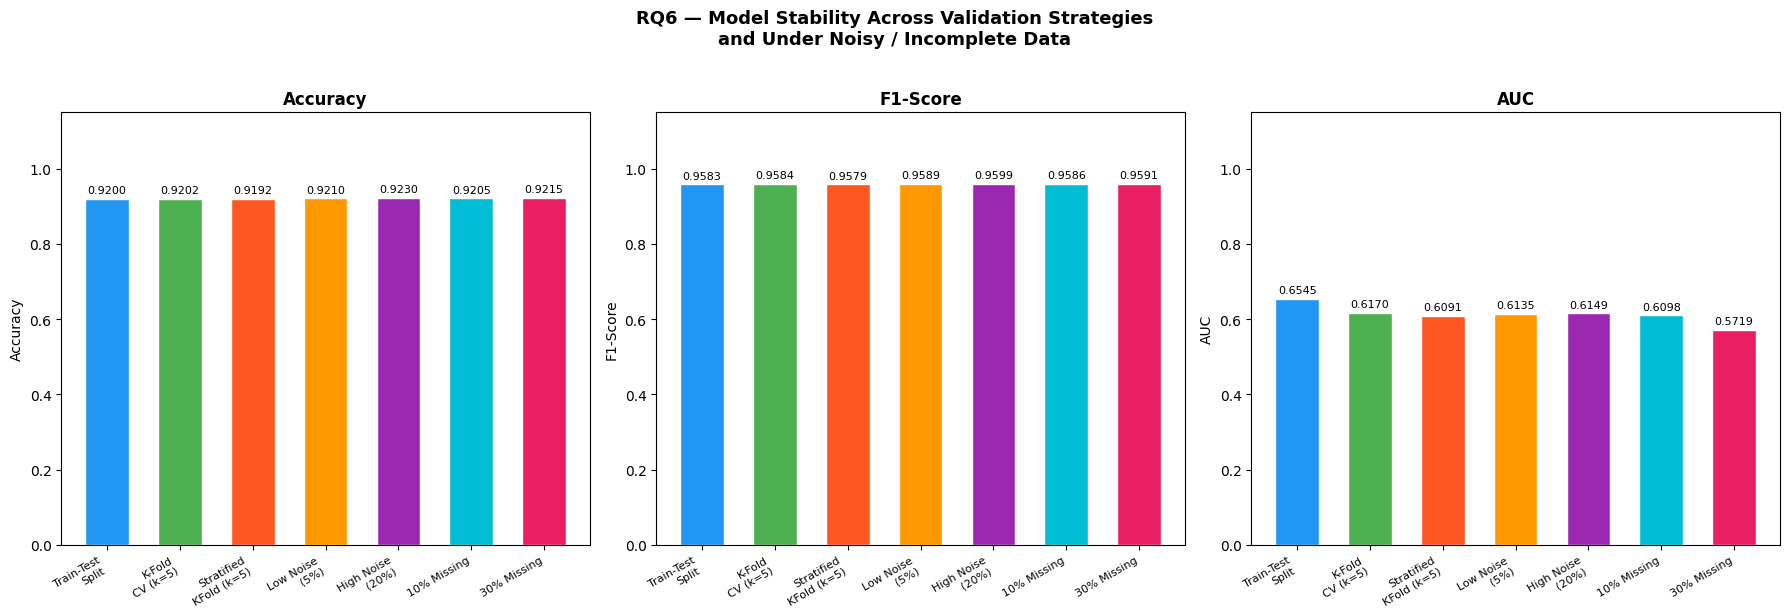

RQ6 — Model Stability Results
                            Experiment  Accuracy  F1-Score    AUC  Std Dev
  Validation: Train-Test Split (80/20)    0.9200    0.9583 0.6545   0.0000
           Validation: K-Fold CV (k=5)    0.9202    0.9584 0.6170   0.0257
Validation: Stratified K-Fold CV (k=5)    0.9192    0.9579 0.6091   0.0065
            Noisy Data: Low Noise (5%)    0.9210    0.9589 0.6135   0.0000
          Noisy Data: High Noise (20%)    0.9230    0.9599 0.6149   0.0000
          Incomplete Data: 10% Missing    0.9205    0.9586 0.6098   0.0000
          Incomplete Data: 30% Missing    0.9215    0.9591 0.5719   0.0000

Stability Summary:
  Best Validation Strategy : Validation: Train-Test Split (80/20)
  Lowest AUC (Stress Test) : Incomplete Data: 30% Missing
  AUC Drop (Best vs Worst) : 0.0826
RQ6 Complete! Files saved: RQ6_table.csv, RQ6_figure.pdf


In [1]:
# ============================================================
# RQ6: How stable is the selected predictive model across
# different validation strategies and under noisy or
# incomplete mental health data?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, KFold,
                                     StratifiedKFold, cross_val_score)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# --- Step 1: Load Dataset ---
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset/mental_health.csv")

# --- Step 2: Encode Categorical Columns ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# --- Step 3: Define Features & Target ---
X = df.drop("Has_Mental_Health_Issue", axis=1)
y = df["Has_Mental_Health_Issue"]

# Base model
model = XGBClassifier(eval_metric='logloss', random_state=42)

results = []

# ============================================================
# EXPERIMENT 1: Validation Strategies
# ============================================================

# 1A: Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
results.append({
    "Experiment":  "Validation: Train-Test Split (80/20)",
    "Accuracy":    round(accuracy_score(y_test, y_pred), 4),
    "F1-Score":    round(f1_score(y_test, y_pred), 4),
    "AUC":         round(roc_auc_score(y_test, y_prob), 4),
    "Std Dev":     round(0.0, 4)
})

# 1B: K-Fold Cross Validation (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc')
results.append({
    "Experiment":  "Validation: K-Fold CV (k=5)",
    "Accuracy":    round(np.mean(cross_val_score(model, X, y, cv=kf, scoring='accuracy')), 4),
    "F1-Score":    round(np.mean(cross_val_score(model, X, y, cv=kf, scoring='f1')), 4),
    "AUC":         round(np.mean(kf_scores), 4),
    "Std Dev":     round(np.std(kf_scores), 4)
})

# 1C: Stratified K-Fold Cross Validation (k=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
results.append({
    "Experiment":  "Validation: Stratified K-Fold CV (k=5)",
    "Accuracy":    round(np.mean(cross_val_score(model, X, y, cv=skf, scoring='accuracy')), 4),
    "F1-Score":    round(np.mean(cross_val_score(model, X, y, cv=skf, scoring='f1')), 4),
    "AUC":         round(np.mean(skf_scores), 4),
    "Std Dev":     round(np.std(skf_scores), 4)
})

# ============================================================
# EXPERIMENT 2: Noisy Data (Random Noise Injected)
# ============================================================

# 2A: Low Noise (5% of numeric values randomly perturbed)
df_low_noise = df.copy()
numeric_cols = df_low_noise.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Has_Mental_Health_Issue"]
np.random.seed(42)
for col in numeric_cols:
    noise = np.random.normal(0, 0.05 * df_low_noise[col].std(), size=len(df_low_noise))
    df_low_noise[col] = df_low_noise[col] + noise
X_noisy = df_low_noise.drop("Has_Mental_Health_Issue", axis=1)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42
)
model.fit(X_train_n, y_train_n)
y_pred = model.predict(X_test_n)
y_prob = model.predict_proba(X_test_n)[:, 1]
results.append({
    "Experiment":  "Noisy Data: Low Noise (5%)",
    "Accuracy":    round(accuracy_score(y_test_n, y_pred), 4),
    "F1-Score":    round(f1_score(y_test_n, y_pred), 4),
    "AUC":         round(roc_auc_score(y_test_n, y_prob), 4),
    "Std Dev":     round(0.0, 4)
})

# 2B: High Noise (20% of numeric values randomly perturbed)
df_high_noise = df.copy()
for col in numeric_cols:
    noise = np.random.normal(0, 0.20 * df_high_noise[col].std(), size=len(df_high_noise))
    df_high_noise[col] = df_high_noise[col] + noise
X_noisy_h = df_high_noise.drop("Has_Mental_Health_Issue", axis=1)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_noisy_h, y, test_size=0.2, random_state=42
)
model.fit(X_train_h, y_train_h)
y_pred = model.predict(X_test_h)
y_prob = model.predict_proba(X_test_h)[:, 1]
results.append({
    "Experiment":  "Noisy Data: High Noise (20%)",
    "Accuracy":    round(accuracy_score(y_test_h, y_pred), 4),
    "F1-Score":    round(f1_score(y_test_h, y_pred), 4),
    "AUC":         round(roc_auc_score(y_test_h, y_prob), 4),
    "Std Dev":     round(0.0, 4)
})

# ============================================================
# EXPERIMENT 3: Incomplete Data (Missing Values Introduced)
# ============================================================

# 3A: 10% Missing Values
df_miss10 = df.copy().astype(float)
for col in numeric_cols:
    missing_idx = np.random.choice(df_miss10.index, size=int(0.10 * len(df_miss10)), replace=False)
    df_miss10.loc[missing_idx, col] = np.nan
df_miss10.fillna(df_miss10.mean(), inplace=True)
X_m10 = df_miss10.drop("Has_Mental_Health_Issue", axis=1)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m10, y, test_size=0.2, random_state=42
)
model.fit(X_train_m, y_train_m)
y_pred = model.predict(X_test_m)
y_prob = model.predict_proba(X_test_m)[:, 1]
results.append({
    "Experiment":  "Incomplete Data: 10% Missing",
    "Accuracy":    round(accuracy_score(y_test_m, y_pred), 4),
    "F1-Score":    round(f1_score(y_test_m, y_pred), 4),
    "AUC":         round(roc_auc_score(y_test_m, y_prob), 4),
    "Std Dev":     round(0.0, 4)
})

# 3B: 30% Missing Values
df_miss30 = df.copy().astype(float)
for col in numeric_cols:
    missing_idx = np.random.choice(df_miss30.index, size=int(0.30 * len(df_miss30)), replace=False)
    df_miss30.loc[missing_idx, col] = np.nan
df_miss30.fillna(df_miss30.mean(), inplace=True)
X_m30 = df_miss30.drop("Has_Mental_Health_Issue", axis=1)
X_train_m3, X_test_m3, y_train_m3, y_test_m3 = train_test_split(
    X_m30, y, test_size=0.2, random_state=42
)
model.fit(X_train_m3, y_train_m3)
y_pred = model.predict(X_test_m3)
y_prob = model.predict_proba(X_test_m3)[:, 1]
results.append({
    "Experiment":  "Incomplete Data: 30% Missing",
    "Accuracy":    round(accuracy_score(y_test_m3, y_pred), 4),
    "F1-Score":    round(f1_score(y_test_m3, y_pred), 4),
    "AUC":         round(roc_auc_score(y_test_m3, y_prob), 4),
    "Std Dev":     round(0.0, 4)
})

# ============================================================
# SAVE & PLOT
# ============================================================

# --- Save Table ---
df_results = pd.DataFrame(results)
df_results.to_csv("RQ6_table.csv", index=False)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ["Accuracy", "F1-Score", "AUC"]
colors = ['#2196F3', '#4CAF50', '#FF5722',
          '#FF9800', '#9C27B0', '#00BCD4', '#E91E63']
short_labels = [
    "Train-Test\nSplit",
    "K-Fold\nCV (k=5)",
    "Stratified\nKFold (k=5)",
    "Low Noise\n(5%)",
    "High Noise\n(20%)",
    "10% Missing",
    "30% Missing"
]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        range(len(df_results)),
        df_results[metric],
        color=colors[:len(df_results)],
        edgecolor='white',
        width=0.6
    )
    ax.set_title(f"{metric}", fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle("RQ6 — Model Stability Across Validation Strategies\nand Under Noisy / Incomplete Data",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("RQ6_figure.pdf", bbox_inches='tight')
plt.show()

# --- Print Results ---
print("=" * 75)
print("RQ6 — Model Stability Results")
print("=" * 75)
print(df_results.to_string(index=False))
print("=" * 75)
print("\nStability Summary:")
print(f"  Best Validation Strategy : {df_results.loc[df_results['AUC'].idxmax(), 'Experiment']}")
print(f"  Lowest AUC (Stress Test) : {df_results.loc[df_results['AUC'].idxmin(), 'Experiment']}")
print(f"  AUC Drop (Best vs Worst) : {round(df_results['AUC'].max() - df_results['AUC'].min(), 4)}")
print("=" * 75)
print("RQ6 Complete! Files saved: RQ6_table.csv, RQ6_figure.pdf")